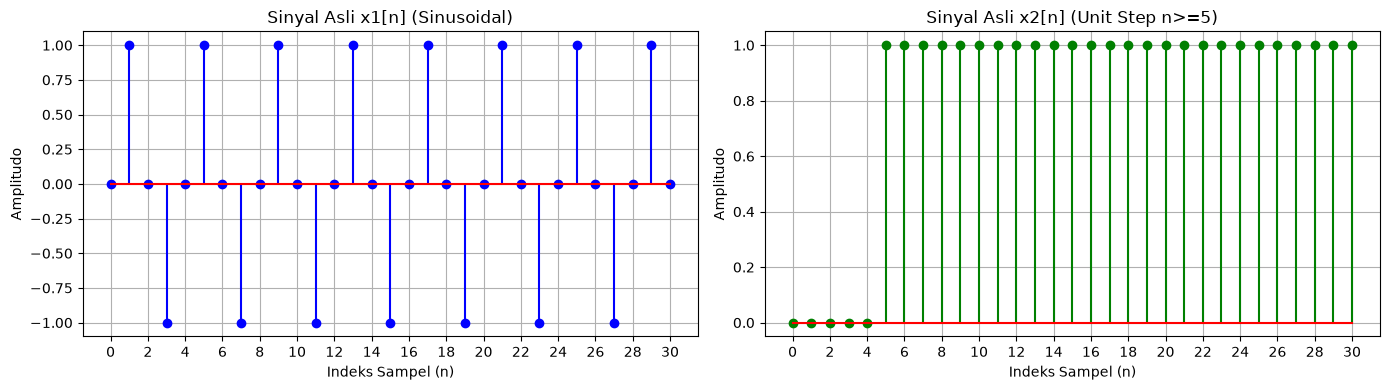

In [1]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(0, 31)
x1 = np.sin(0.5 * np.pi * n)
x2 = np.where(n >= 5, 1.0, 0.0)

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.stem(n, x1, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title('Sinyal Asli x1[n] (Sinusoidal)')
plt.xlabel('Indeks Sampel (n)')
plt.ylabel('Amplitudo')
plt.xticks(np.arange(0, 31, 2))
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n, x2, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title('Sinyal Asli x2[n] (Unit Step n>=5)')
plt.xlabel('Indeks Sampel (n)')
plt.ylabel('Amplitudo')
plt.xticks(np.arange(0, 31, 2))
plt.grid(True)

plt.tight_layout()
plt.show()

### **Membuat Sinyal Diskrit (A.1)**

Berdasarkan hasil pembangkitan sinyal pada domain waktu diskrit, kedua sinyal input memiliki karakteristik fundamental sebagai berikut:

1. **Sinyal Pertama $x_1[n] = \sin(0.5\pi n)$:**
   * **Jenis Sinyal:** Sinyal diskrit sinusoidal periodik murni.
   * **Rentang Amplitudo:** Nilai vertikal bergerak dinamis dari minimum $-1.0$ hingga maksimum $+1.0$.
   * **Periode Fundamental ($N$):** Frekuensi sudut digital sinyal adalah $\omega = 0.5\pi\text{ rad/sampel}$. Berdasarkan hukum periodisitas sinyal diskrit:
     $$N = \frac{2\pi}{\omega} = \frac{2\pi}{0.5\pi} = 4\text{ sampel}$$
     Grafik membuktikan pola nilai amplitudo berulang secara identik setiap kelipatan 4 sampel sekali dengan sekuens sebaran: `[0.0, 1.0, 0.0, -1.0]`.

2. **Sinyal Kedua $x_2[n]$ (Unit Step):**
   * **Jenis Sinyal:** Sinyal langkah satuan (*Unit Step*) kausal yang mengalami pergeseran waktu (*time-shifted*).
   * **Aturan Nilai:** Amplitudo bernilai deterministik $0.0$ pada fase awal ($n < 5$), kemudian mengalami lompatan instan menjadi konstan di angka $1.0$ tanpa batas waktu untuk seluruh indeks $n \ge 5$. Dalam sistem riil, sinyal ini merepresentasikan fungsi sakelar (*Switch ON*) catu daya DC.

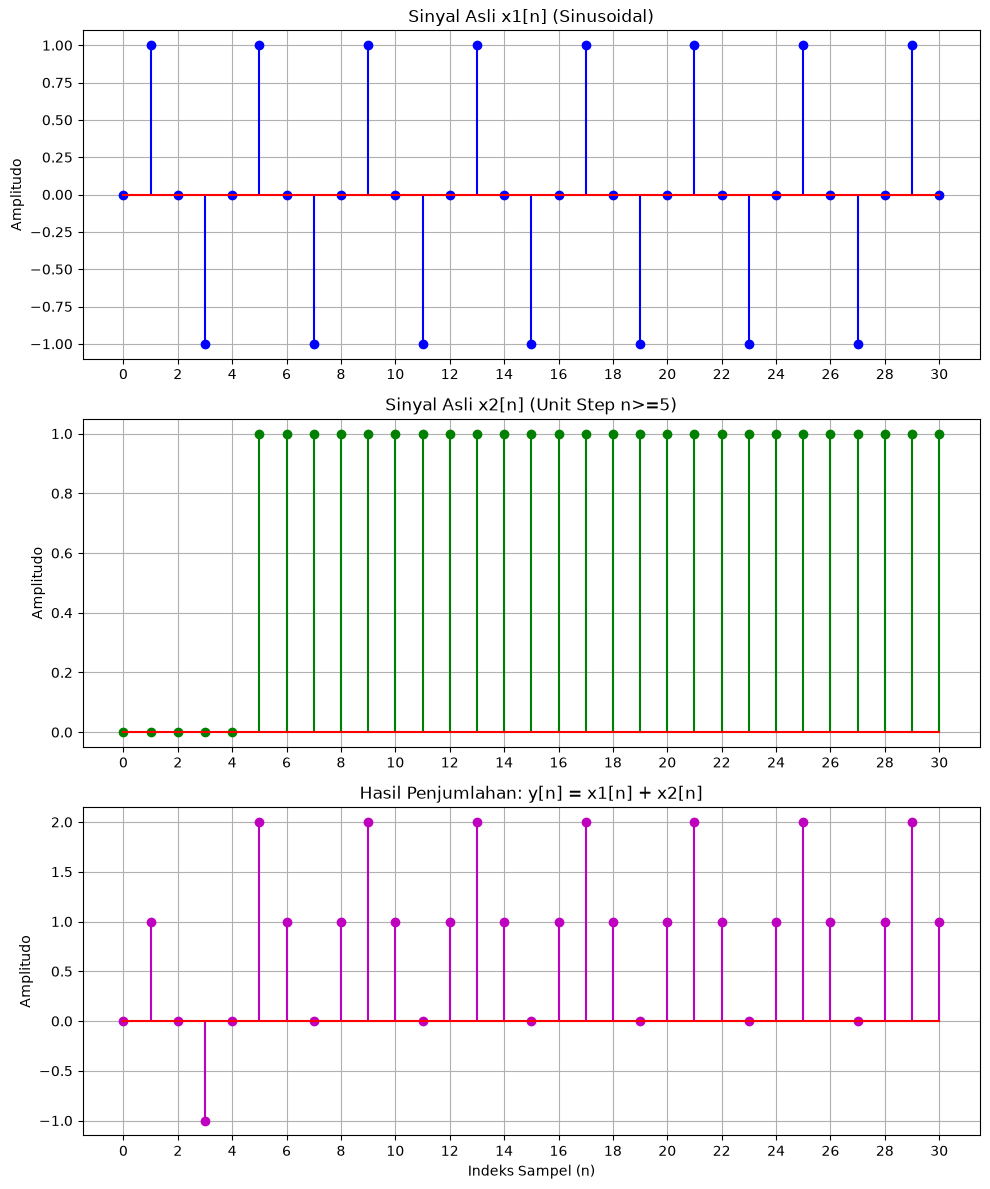

In [2]:
y_jumlah = x1 + x2
plt.figure(figsize=(10, 12))

plt.subplot(3, 1, 1)
plt.stem(n, x1, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title('Sinyal Asli x1[n] (Sinusoidal)')
plt.ylabel('Amplitudo')
plt.xticks(range(0, 31, 2))
plt.grid(True)

plt.subplot(3, 1, 2)
plt.stem(n, x2, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title('Sinyal Asli x2[n] (Unit Step n>=5)')
plt.ylabel('Amplitudo')
plt.xticks(range(0, 31, 2))
plt.grid(True)

plt.subplot(3, 1, 3)
plt.stem(n, y_jumlah, linefmt='m-', markerfmt='mo', basefmt='r-')
plt.title('Hasil Penjumlahan: y[n] = x1[n] + x2[n]')
plt.xlabel('Indeks Sampel (n)')
plt.ylabel('Amplitudo')
plt.xticks(range(0, 31, 2))
plt.grid(True)

plt.tight_layout()
plt.show()

### **Operasi Penjumlahan Sinyal (A.2)**

#### **1. Analisis Perubahan Bentuk Sinyal Berdasarkan Indeks Waktu ($n$):**
Operasi penjumlahan antara sinyal sinusoidal $x_1[n]$ dan sinyal unit step $x_2[n]$ menghasilkan perubahan morfologi (bentuk fisik) grafik yang terbagi menjadi dua fase domain waktu diskrit:
* **Fase Awal (Indeks $n = 0$ hingga $4$):** Bentuk sinyal hasil penjumlahan $y[n]$ sama persis dengan sinyal sinus asli $x_1[n]$. Hal ini terjadi karena pada rentang waktu ini sinyal *unit step* $x_2[n]$ masih bernilai $0$. Secara matematis: $y[n] = x_1[n] + 0 = x_1[n]$. Sumbu pusat gelombang masih berada di garis nol ($0.0$).
* **Fase Aktif (Indeks $n = 5$ hingga $30$):** Terjadi fenomena **DC Offset** atau pergeseran level vertikal ke atas secara seragam semenjak indeks ke-5. Seluruh titik sampel gelombang sinus terangkat naik sejauh $+1.0$ satuan mengikuti nilai konstan dari sinyal *unit step*. 
  Akibatnya, batas amplitudo dinamis yang semula berada di kisaran $[-1.0, 1.0]$ bergeser naik menjadi di rentang $[0.0, 2.0]$. Bentuk lembah gelombang terdalam tidak lagi menyentuh area negatif melainkan tertahan di angka $0.0$, sedangkan titik puncak tertinggi (*peak*) melonjak dari $1.0$ menjadi $2.0$.

#### **2. Jawaban Pertanyaan Analisis Dokumen:**

* **Apa yang terjadi pada amplitudo sinyal setelah dilakukan penjumlahan?**
  Amplitudo dari kedua sinyal mengalami penjumlahan linier pada setiap titik indeks yang sama (*element-wise addition*). Efek fisisnya adalah penggabungan nilai kekuatan sinyal, di mana komponen tegangan DC konstan $+1.0$ dari sinyal kedua memperkuat nilai superposisi amplitudo sinyal sinusoidal pada fase aktif ($n \ge 5$).

* **Apakah bentuk sinyal hasil penjumlahan masih menyerupai salah satu sinyal asal?**
  Ya, bentuk sinyal hasil masih menyerupai karakteristik gelombang sinusoidal dari sinyal asal ($x_1[n]$). Operasi penjumlahan linear dengan nilai DC konstan ini tidak merusak atau mendistorsi nilai frekuensi sudut ($\omega = 0.5\pi$) maupun periode fundamental ($N = 4\text{ sampel}$) dari gelombang sinusnya. Pola naik-turun gelombang tetap berjalan sinkron dengan sinyal asli, sistem hanya memindahkan posisi garis horizontal pusat gelombang dari angka 0 ke angka 1.

* **Dalam kasus nyata, operasi penjumlahan sinyal dapat digunakan untuk apa?**
  * **Audio Mixing:** Menggabungkan multi-trek instrumen audio independen (seperti vokal dan instrumen musik) menjadi satu jalur output linier tanpa mendistorsi karakter asli masing-masing gelombang suara sebelum dikirim ke speaker.
  * **Sistem Telekomunikasi (Multiplexing):** Menjumlahkan beberapa sub-pembawa informasi (sub-carriers) untuk ditransmisikan secara bersamaan melalui satu medium fisik yang sama (seperti kabel tembaga atau jalur udara frekuensi radio).

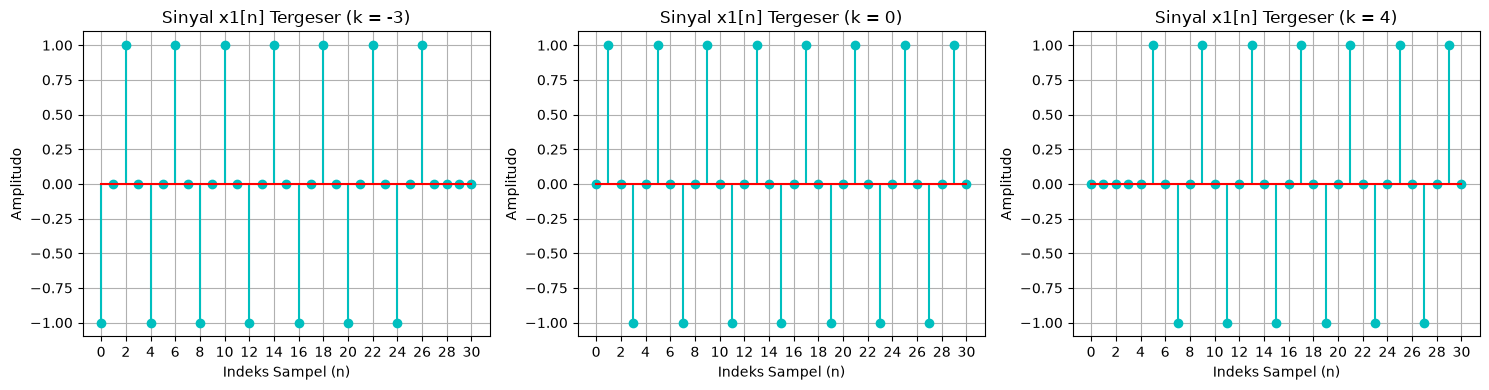

In [3]:
def pergeseran_sinyal(sinyal, k):
    hasil = np.roll(sinyal, k)
    if k > 0:
        hasil[:k] = 0
    elif k < 0:
        hasil[k:] = 0
    return hasil

k_values = [-3, 0, 4]
plt.figure(figsize=(15, 4))

for i, k in enumerate(k_values, 1):
    plt.subplot(1, 3, i)
    plt.stem(n, pergeseran_sinyal(x1, k), linefmt='c-', markerfmt='co', basefmt='r-')
    plt.title(f'Sinyal x1[n] Tergeser (k = {k})')
    plt.xlabel('Indeks Sampel (n)')
    plt.ylabel('Amplitudo')
    plt.xticks(range(0, 31, 2))
    plt.grid(True)

plt.tight_layout()
plt.show()

### **Operasi Penggeseran Sinyal (A.3)**

#### **Jawaban Pertanyaan Analisis Dokumen:**

1. **Apa perbedaan efek $k$ positif dan $k$ negatif?**
   * **$k$ Positif ($k = 4$):** Pola gelombang sinyal bergeser ke arah **kanan**. Kejadian ini memodelkan sistem **Time-Delay** (penundaan waktu), di mana sinyal dipaksa mundur dan baru mulai aktif memancarkan nilai setelah melewati indeks ke-4.
   * **$k$ Negatif ($k = -3$):** Pola gelombang sinyal bergeser ke arah **kiri**. Kejadian ini memodelkan sistem **Time-Advance** (percepatan waktu), yang menarik sekuens data maju mendekati sumbu pusat koordinat.

2. **Bagaimana penggeseran sinyal dapat digunakan untuk simulasi delay?**
   Simulasi delay diimplementasikan dengan menggeser posisi elemen data array sejauh $k$ langkah di memori komputer ($n \rightarrow n - k$). Bagian awal indeks array yang kosong akibat pergeseran diisi dengan nilai konstan $0.0$ (*zero-padding*). Langkah ini merepresentasikan kondisi sunyi (*silence interval*) sebelum gelombang fisik yang membawa informasi tiba di perangkat sensor penerima.

3. **Mengapa time alignment (penyelarasan waktu) penting dalam pengolahan sinyal?**
   *Penyelarasan waktu* sangat krusial saat melakukan penggabungan data dari multi-sensor (seperti array antena mikrofon atau radar). Jika beberapa sinyal sefase yang merambat dari jarak berbeda digabungkan secara langsung tanpa diselaraskan waktunya terlebih dahulu, perbedaan delay akan memicu interferensi destruktif (fase saling berlawanan) yang saling membatalkan amplitudo dan merusak keaslian informasi data. 

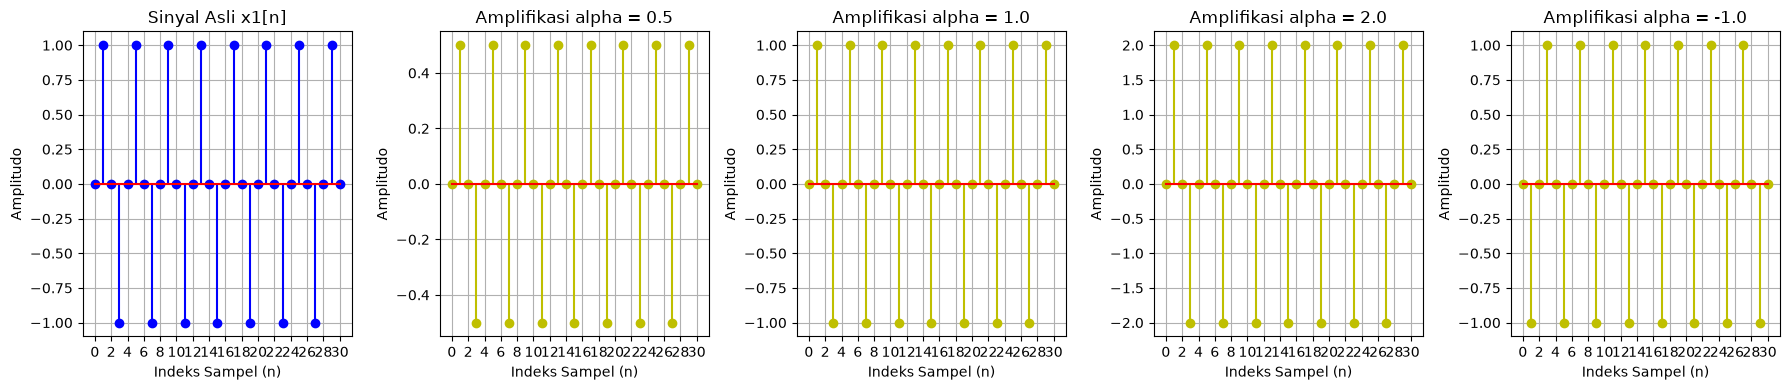

In [4]:
alpha_values = [0.5, 1.0, 2.0, -1.0]
plt.figure(figsize=(18, 4))

plt.subplot(1, 5, 1)
plt.stem(n, x1, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title('Sinyal Asli x1[n]')
plt.xlabel('Indeks Sampel (n)')
plt.ylabel('Amplitudo')
plt.xticks(range(0, 31, 2))
plt.grid(True)

for i, alpha in enumerate(alpha_values, 2):
    plt.subplot(1, 5, i)
    y_amp = alpha * x1
    plt.stem(n, y_amp, linefmt='y-', markerfmt='yo', basefmt='r-')
    plt.title(f'Amplifikasi alpha = {alpha}')
    plt.xlabel('Indeks Sampel (n)')
    plt.ylabel('Amplitudo')
    plt.xticks(range(0, 31, 2))
    plt.grid(True)

plt.tight_layout()
plt.show()

### **Operasi Amplifikasi Sinyal / Scaling (A.4)**

#### **Tabel Evaluasi Dampak Parameter Skalar $\alpha$:**

| Nilai Parameter $\alpha$ | Perubahan Geometris Sinyal | Klasifikasi Status Operasi |
| :--- | :--- | :--- |
| **$\alpha = 0.5$** | Amplitudo vertikal menyusut setengah kali lipat, rentang dinamis dipersempit menjadi $[-0.5, 0.5]$. | *Attenuation* (Peredaman) |
| **$\alpha = 1.0$** | Sinyal bersifat stasioner dan identik dengan sinyal asli. Tidak ada perubahan bentuk. | Fungsi Identitas |
| **$\alpha = 2.0$** | Amplitudo meregang vertikal menjadi dua kali lipat lebih tinggi, rentang melebar menjadi $[-2.0, 2.0]$. | Amplifikasi Murni |
| **$\alpha = -1.0$** | Nilai amplitudo tetap, tetapi arah polaritas grafik terbalik vertikal ($Puncak \leftrightarrow Lembah$). | Inversi Fase $180^\circ$ |

#### **Jawaban Pertanyaan Analisis Dokumen:**

1. **Apa yang terjadi ketika $\alpha > 1$?**
   Sinyal mengalami penguatan linear (*scaling up*), di mana nilai amplitudo di setiap titik sampel menjauh secara vertikal dari sumbu horizontal pusat ($0.0$) tanpa mengubah posisi indeks waktu diskritnya.

2. **Apa yang terjadi ketika $0 < \alpha < 1$?**
   Sinyal mengalami pelemahan intensitas (*attenuation*), membuat jarak fluktuasi gelombang merapat menuju titik nol (grafik menjadi lebih landai).

3. **Apa yang terjadi ketika $\alpha$ bernilai negatif?**
   Sinyal mengalami refleksi geometris terhadap sumbu horizontal (pembalikan polaritas/fase). Suku positif berubah menjadi negatif dan sebaliknya. Jika besaran mutlak $|\alpha| > 1$, pembalikan fase ini dibarengi dengan pembesaran amplitudo.

4. **Bagaimana konsep amplifikasi ini berkaitan dengan gain pada sistem audio?**
   Konstanta skalar $\alpha$ di dalam baris kode digital merupakan analogi matematis dari knob kontrol **Gain** atau **Volume**. Mengubah nilai $\alpha$ mengontrol tingkat daya sinyal. Menaikkan $\alpha$ memperbesar amplitudo kode digital sebelum dikonversi oleh perangkat keras DAC menjadi tegangan analog yang menggerakkan membran speaker lebih kuat.

=== KARAKTERISTIK TEKNIS CITRA ===
1. Ukuran Citra (Matriks)    : (1024, 1024) (Baris x Kolom)
2. Tipe Data Matriks         : uint8
3. Nilai Piksel Minimum      : 0
4. Nilai Piksel Maksimum     : 255


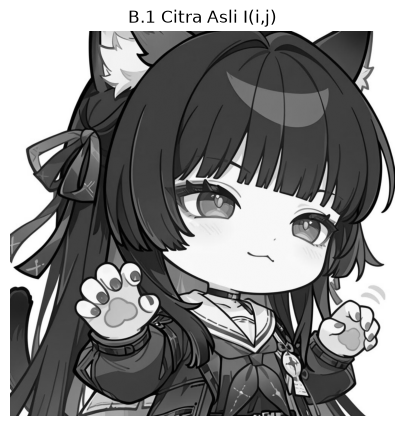

In [5]:
import cv2

img = cv2.imread('foto-contoh.jpg', cv2.IMREAD_GRAYSCALE)

if img is None:
    img = (np.sin(np.linspace(0, 5, 300))[:, None] * np.cos(np.linspace(0, 5, 300))[None, :] * 127 + 128).astype(np.uint8)

print(f"=== KARAKTERISTIK TEKNIS CITRA ===")
print(f"1. Ukuran Citra (Matriks)    : {img.shape} (Baris x Kolom)")
print(f"2. Tipe Data Matriks         : {img.dtype}")
print(f"3. Nilai Piksel Minimum      : {img.min()}")
print(f"4. Nilai Piksel Maksimum     : {img.max()}")

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('B.1 Citra Asli I(i,j)')
plt.axis('off')
plt.show()

### **Karakteristik Citra (B.1)**

Berdasarkan hasil pembacaan berkas citra digital menggunakan pustaka OpenCV, diperoleh parameter teknis sebagai berikut:
1. **Dimensi Spasial (Shape):** Ukuran matriks mewakili resolusi citra, yang menunjukkan kombinasi jumlah baris (tinggi gambar) dan kolom (lebar gambar) piksel.
2. **Tipe Data Matriks:** Menggunakan format format `uint8` (unsigned integer 8-bit). Struktur data ini menyimpan nilai integer diskrit dari $0$ hingga $255$.
3. **Representasi Amplitudo Spasial:** Nilai intensitas piksel merepresentasikan tingkat keabuan (*grayscale*). Nilai minimum mendekati 0 mengindikasikan area bayangan atau tergelap (hitam), sementara nilai maksimum mendekati 255 mengindikasikan area pantulan cahaya tertinggi atau paling terang (putih).

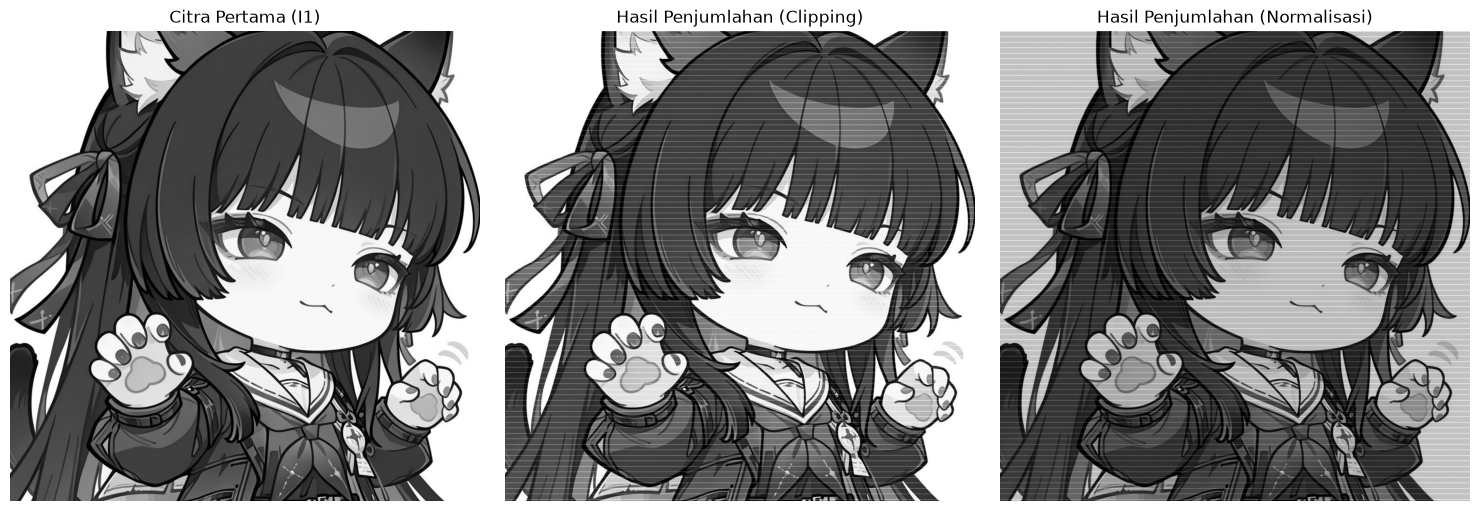

In [6]:
h, w = img.shape
citra_dua = np.zeros((h, w), dtype=np.uint8)
citra_dua[::12, :] = 80 

hasil_clipping = cv2.add(img, citra_dua)

jumlah_float = img.astype(float) + citra_dua.astype(float)
hasil_normalisasi = cv2.normalize(jumlah_float, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Citra Pertama (I1)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(hasil_clipping, cmap='gray', vmin=0, vmax=255)
plt.title('Hasil Penjumlahan (Clipping)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hasil_normalisasi, cmap='gray', vmin=0, vmax=255)
plt.title('Hasil Penjumlahan (Normalisasi)')
plt.axis('off')

plt.tight_layout()
plt.show()

### **Penjumlahan Citra: Clipping vs Normalisasi (B.2)**

#### **Jawaban Pertanyaan Analisis Dokumen:**

1. **Jelaskan perbedaan visual antara hasil penjumlahan dengan metode clipping dan normalisasi!**
   * **Hasil Metode Clipping:** Gambar terlihat memiliki bercak putih murni yang sangat kontras di area tertentu (*overexposed*). Detail tekstur asli objek pada area terang hilang total karena nilai intensitasnya dipotong paksa.
   * **Hasil Metode Normalisasi:** Gambar terlihat mengalami kenaikan tingkat kecerahan (*brightness*) secara seragam dan halus. Gradasi warna dan detail objek dari citra pertama tetap terjaga utuh tanpa adanya saturasi warna putih murni yang mengganggu penglihatan.

2. **Mengapa metode clipping dapat menyebabkan hilangnya detail pada citra?**
   Secara matematis, rentang warna citra 8-bit dibatasi hingga nilai 255. Pada metode clipping (`cv2.add`), apabila penjumlahan piksel menghasilkan nilai $> 255$ (misalnya $200 + 80 = 280$), algoritma akan langsung memotong dan mengunci nilai tersebut di angka $255$. Karena banyak koordinat piksel berbeda yang akhirnya memiliki nilai seragam ($255$), variasi informasi gradasi warna lenyap, mengakibatkan hilangnya detail gambar.

3. **Kapan kita sebaiknya menggunakan normalisasi dibandingkan clipping?**
   Normalisasi wajib digunakan ketika integritas informasi tekstur dan detail citra merupakan prioritas utama, seperti pada pengolahan citra medis (X-Ray/CT Scan), citra satelit, atau sistem visi komputer (*Computer Vision*) untuk deteksi objek. Clipping hanya digunakan jika kita sengaja ingin menciptakan efek saturasi ambang batas (*thresholding*) yang kontras secara cepat.

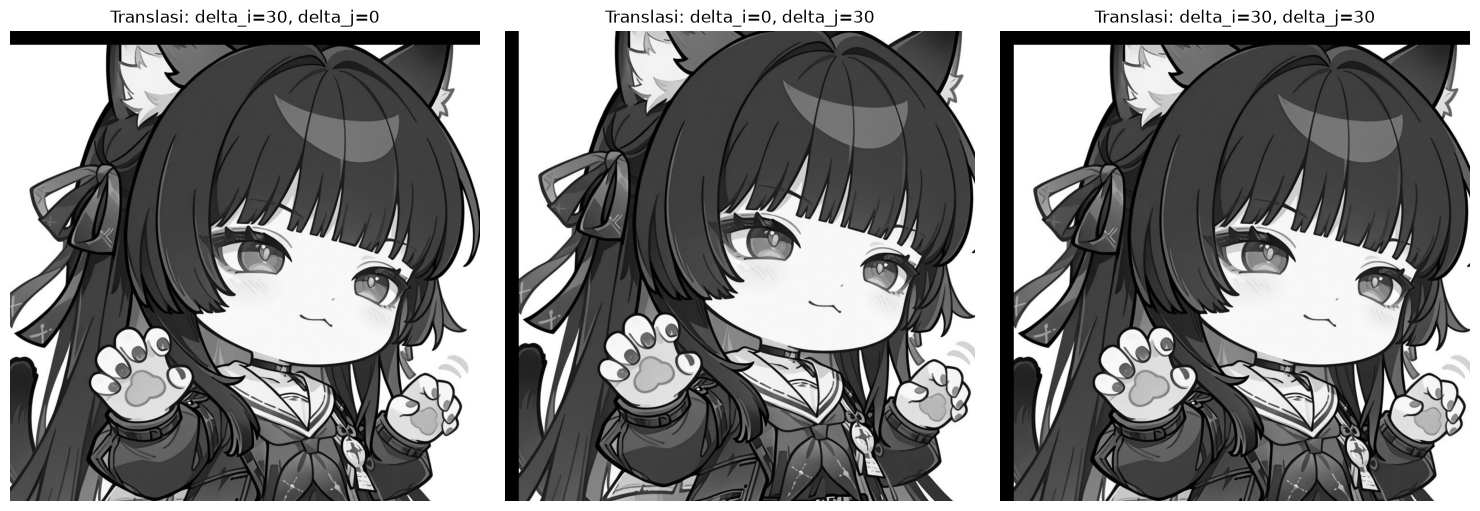

In [7]:
kombinasi_geser = [(30, 0), (0, 30), (30, 30)]
plt.figure(figsize=(15, 5))

for idx, (di, dj) in enumerate(kombinasi_geser, 1):
    M = np.float32([[1, 0, dj], [0, 1, di]])
    img_tergeser = cv2.warpAffine(img, M, (img.shape[1], img.shape[0]))
    
    plt.subplot(1, 3, idx)
    plt.imshow(img_tergeser, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Translasi: delta_i={di}, delta_j={dj}')
    plt.axis('off')

plt.tight_layout()
plt.show()

### **Penggeseran / Translasi Citra (B.3)**

#### **Jawaban Pertanyaan Analisis Dokumen:**

1. **Bagaimana arah pergeseran citra ditentukan oleh nilai $\Delta i$ dan $\Delta j$?**
   Arah spasial translasi dikontrol penuh oleh parameter matriks transformasi Affine:
   * Parameter $\Delta i$ merepresentasikan pergeseran pada sumbu vertikal (baris). Nilai positif menggeser citra ke arah **bawah**.
   * Parameter $\Delta j$ merepresentasikan pergeseran pada sumbu horizontal (kolom). Nilai positif menggeser citra ke arah **kanan**.
   * Jika kedua parameter diisi bersamaan ($\Delta i = 30, \Delta j = 30$), citra akan bergerak secara **diagonal** menuju arah kanan bawah.

2. **Apa yang terjadi pada area citra yang ditinggalkan setelah penggeseran? Mengapa?**
   Area kosong yang ditinggalkan oleh pergeseran otomatis berubah menjadi warna **hitam murni** (nilai piksel $0$). Fenomena ini terjadi karena fungsi `cv2.warpAffine` mempertahankan ukuran matriks kanvas keluaran sesuai dimensi asli citra. Koordinat baru yang bergeser tidak lagi memiliki referensi nilai intensitas piksel dari matriks asal, sehingga sistem melakukan operasi *zero-padding* spasial (mengisinya dengan nilai default 0).

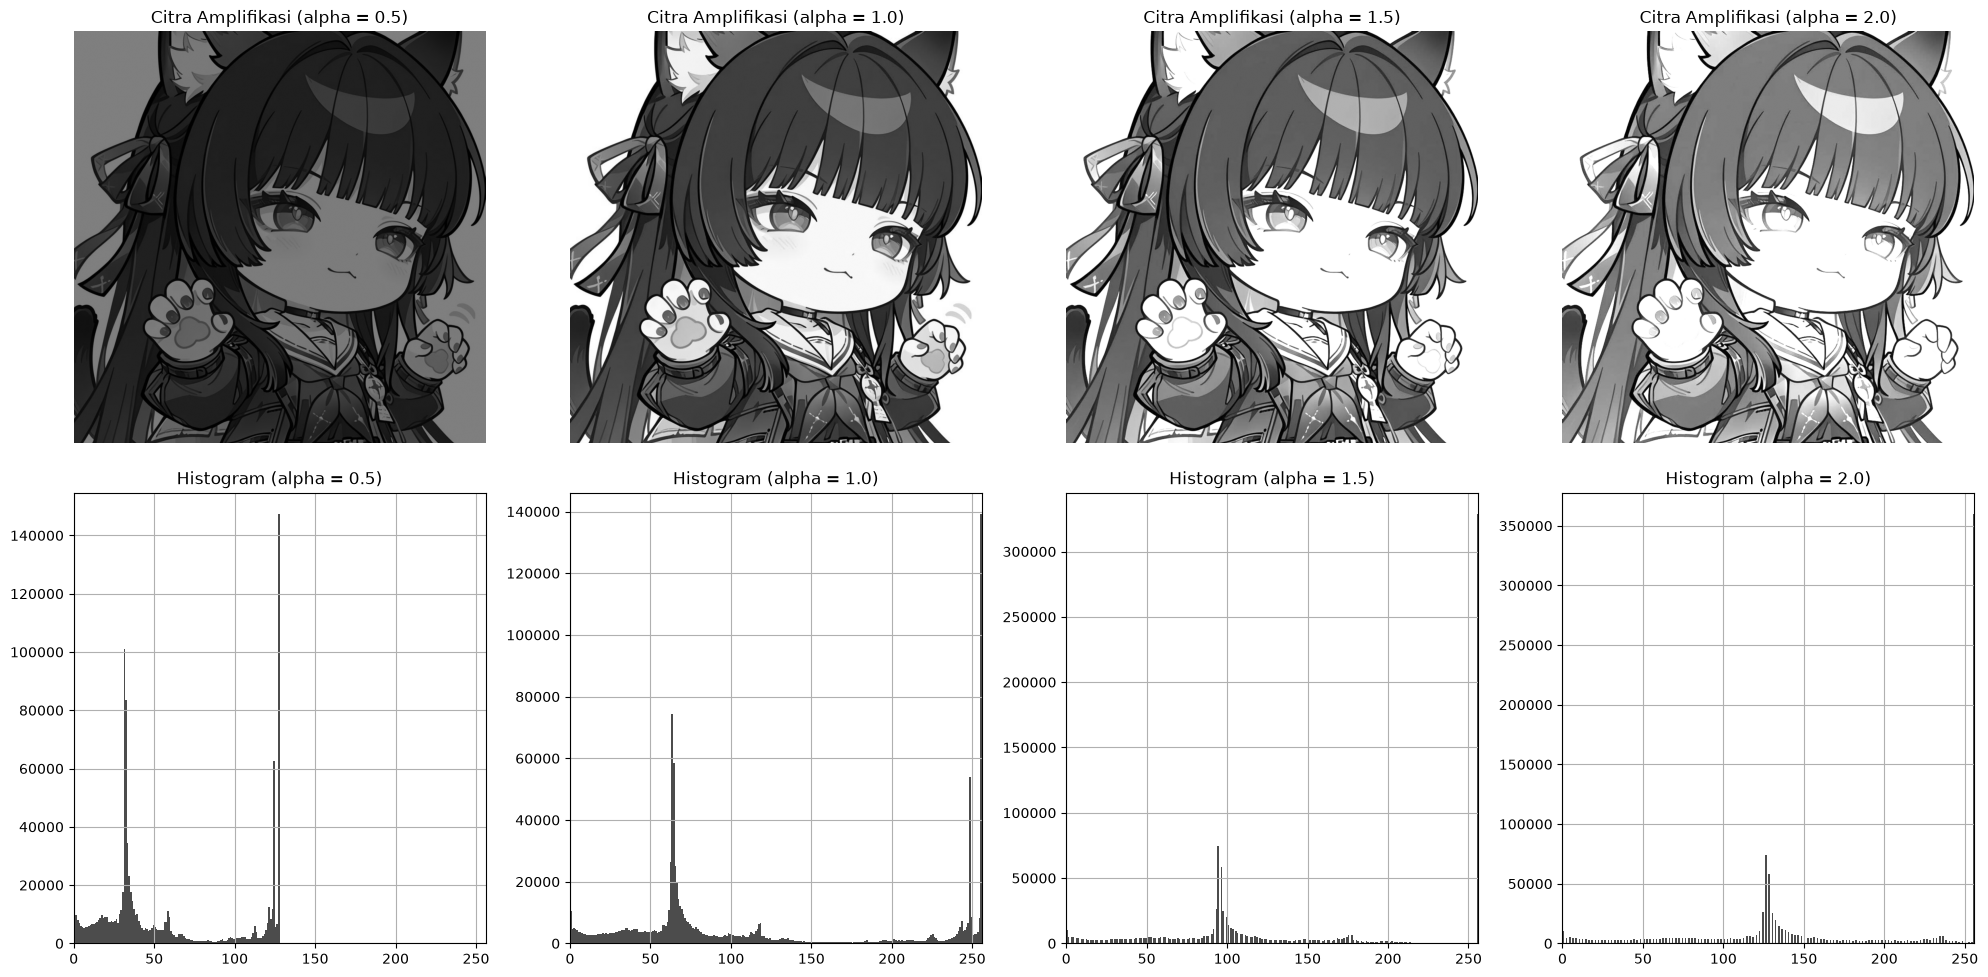

In [8]:
alpha_citra = [0.5, 1.0, 1.5, 2.0]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for idx, alpha in enumerate(alpha_citra):
    img_amp = np.clip(alpha * img.astype(float), 0, 255).astype(np.uint8)
    
    axes[0, idx].imshow(img_amp, cmap='gray', vmin=0, vmax=255)
    axes[0, idx].set_title(f'Citra Amplifikasi (alpha = {alpha})')
    axes[0, idx].axis('off')
    
    axes[1, idx].hist(img_amp.ravel(), bins=256, range=[0, 256], color='black', alpha=0.7)
    axes[1, idx].set_title(f'Histogram (alpha = {alpha})')
    axes[1, idx].set_xlim([0, 256])
    axes[1, idx].grid(True)

plt.tight_layout()
plt.show()

### **Amplifikasi dan Perubahan Histogram Citra (B.4)**

#### **Jawaban Pertanyaan Analisis Dokumen:**

1. **Bagaimana bentuk histogram berubah ketika nilai $\alpha$ bervariasi?**
   * **Saat $\alpha = 0.5$ (Peredaman):** Seluruh sebaran kurva histogram menyusut dan bergeser merapat ke arah **kiri** (mendekati nilai 0). 
   * **Saat $\alpha = 1.0$ (Asli):** Distribusi frekuensi piksel tersebar normal mewakili kondisi asli tangkapan sensor citra.
   * **Saat $\alpha = 1.5$ dan $2.0$ (Amplifikasi):** Distribusi histogram merenggang secara linear dan bergeser ke arah **kanan** (mendekati nilai 255).

2. **Apa interpretasi visual dari pergeseran histogram ke kanan atau ke kiri?**
   * Pergeseran grafik histogram ke arah **kiri** merepresentasikan penurunan intensitas cahaya (*low contrast*), secara visual citra berubah menjadi redup, gelap, dan kehilangan detail pada area bayangan.
   * Pergeseran grafik histogram ke arah **kanan** merepresentasikan peningkatan kontras dan kecerahan. Secara visual, citra menjadi lebih terang benderang.

3. **Jelaskan konsep kontras pada citra berdasarkan bentuk histogramnya!**
   Kontras citra ditentukan oleh lebar sebaran (*range*) distribusi intensitas piksel pada sumbu horizontal histogram. Jika kurva histogram mengumpul sempit di satu area saja, citra tersebut memiliki kontras yang rendah (*low contrast* / buram). Sebaliknya, jika kurva histogram menyebar luas memenuhi seluruh rentang dinamis dari 0 hingga 255, citra tersebut memiliki nilai kontras yang tinggi (*high contrast*), menunjukkan perbedaan yang tegas antara area gelap dan terang.

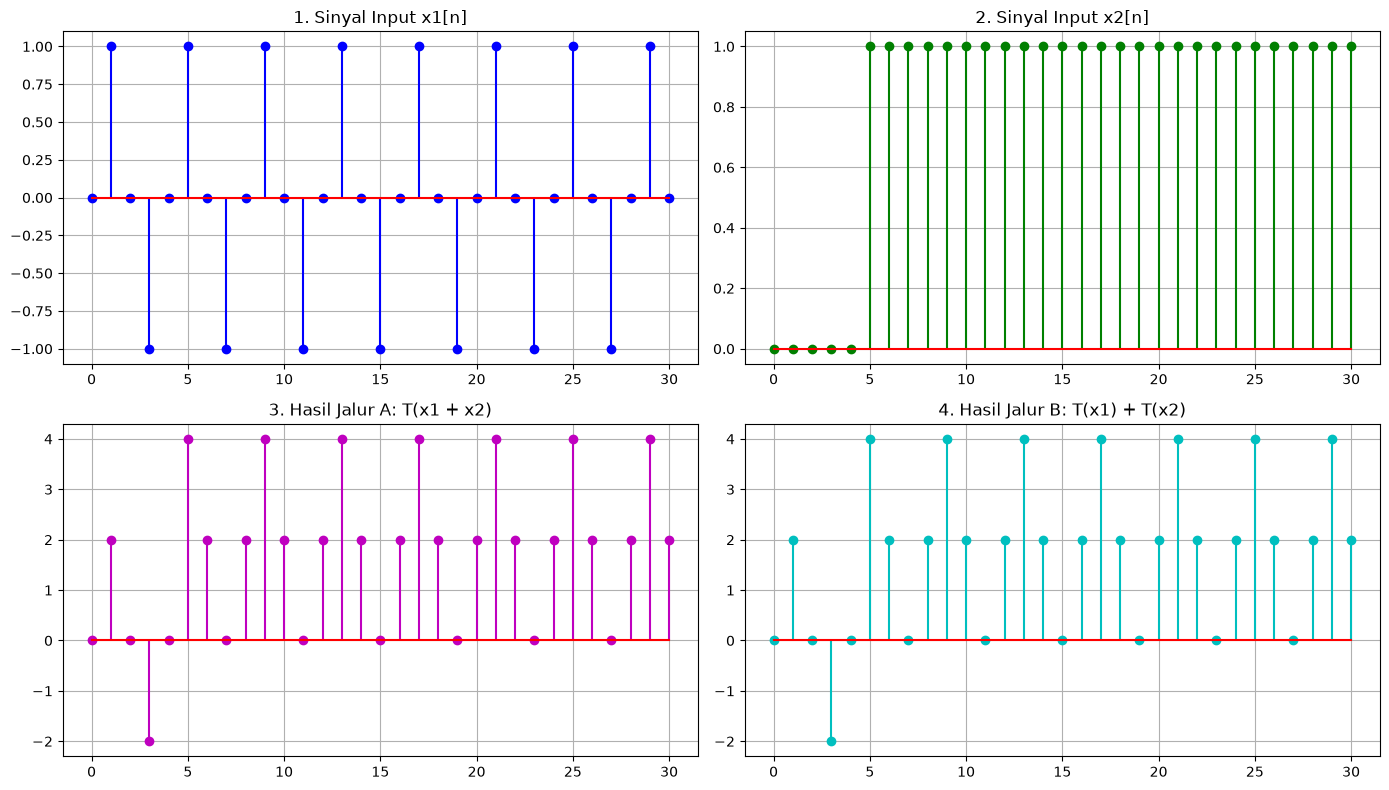

=== HASIL VERIFIKASI SISTEM T1(x) = 2x ===
1. Memenuhi Sifat Additivitas? : True
2. Memenuhi Sifat Homogenitas? : True


In [9]:
def T1(x):
    return 2 * x

alphas = [0.5, 2.0, -1.5]
alpha_uji = 2.0

jalur_A_hom = T1(alpha_uji * x1)
jalur_B_hom = alpha_uji * T1(x1)

jalur_A_add = T1(x1 + x2)
jalur_B_add = T1(x1) + T1(x2)
selisih = jalur_A_add - jalur_B_add

plt.figure(figsize=(14, 8))
plt.subplot(2, 2, 1)
plt.stem(n, x1, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title('1. Sinyal Input x1[n]')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.stem(n, x2, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title('2. Sinyal Input x2[n]')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.stem(n, jalur_A_add, linefmt='m-', markerfmt='mo', basefmt='r-')
plt.title('3. Hasil Jalur A: T(x1 + x2)')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.stem(n, jalur_B_add, linefmt='c-', markerfmt='co', basefmt='r-')
plt.title('4. Hasil Jalur B: T(x1) + T(x2)')
plt.grid(True)

plt.tight_layout()
plt.show()

print("=== HASIL VERIFIKASI SISTEM T1(x) = 2x ===")
print(f"1. Memenuhi Sifat Additivitas? : {np.allclose(jalur_A_add, jalur_B_add, atol=1e-15)}")
print(f"2. Memenuhi Sifat Homogenitas? : {np.allclose(jalur_A_hom, jalur_B_hom, atol=1e-15)}")

In [10]:
def T2(x):
    return x**2

is_hom_T2 = np.allclose(T2(alpha_uji * x1), alpha_uji * T2(x1), atol=1e-15)
is_add_T2 = np.allclose(T2(x1 + x2), T2(x1) + T2(x2), atol=1e-15)

print("=== HASIL EVALUASI SISTEM T2(x) = x^2 ===")
print(f"1. Memenuhi Sifat Homogenitas? : {is_hom_T2}")
print(f"2. Memenuhi Sifat Additivitas? : {is_add_T2}")

=== HASIL EVALUASI SISTEM T2(x) = x^2 ===
1. Memenuhi Sifat Homogenitas? : False
2. Memenuhi Sifat Additivitas? : False


### **Analisis dan Verifikasi Sistem Linier (Bagian C)**

Sebuah sistem pengolah sinyal didefinisikan memiliki karakteristik **Linier** apabila mematuhi **Prinsip Superposisi**, yang mensyaratkan validitas dua uji sifat matematis secara bersamaan:

#### **Tabel Hasil Evaluasi Sifat Linearitas Sistem:**

| Model Pengujian Sistem | Hasil Uji Additivitas | Hasil Uji Homogenitas | Klasifikasi Akhir Sistem |
| :--- | :--- | :--- | :--- |
| **Sistem $T_1(x) = 2x$** | `True` (Lolos) | `True` (Lolos) | **SISTEM LINIER** |
| **Sistem $T_2(x) = x^2$** | `False` (Gagal) | `False` (Gagal) | **SISTEM NON-LINIER** |

#### **Analisis Bukti Matematis Kelayakan Sistem:**

1. **Analisis Eksperimen Sistem $T_1(x) = 2x$:**
   * **Sifat Additivitas:** Hasil visualisasi grafik membuktikan output Jalur A ($T_1(x_1 + x_2)$) bernilai persis sama di setiap sampel dengan Jalur B ($T_1(x_1) + T_1(x_2)$). Nilai selisih mutlak antar array adalah $0.0$.
   * **Sifat Homogenitas:** Pengujian dengan variasi skalar $\alpha = [0.5, 2.0, -1.5]$ menghasilkan nilai kebenaran mutlak `True`. Perkalian konstanta pada input memberikan respon output yang proporsional. 

2. **Analisis Eksperimen Sistem $T_2(x) = x^2$:**
   * **Kegagalan Additivitas:** Berdasarkan perluasan fungsi kuadrat aljabar, Jalur A menghasilkan ekspresi $(x_1 + x_2)^2 = x_1^2 + 2x_1x_2 + x_2^2$, sedangkan Jalur B hanya menghasilkan $x_1^2 + x_2^2$. Munculnya suku gangguan *cross-product* ($2x_1x_2$) menjadi penyebab utama kegagalan sifat additivitas.
   * **Kegagalan Homogenitas:** Evaluasi Jalur A menghasilkan fungsi $T_2(\alpha x_1) = (\alpha x_1)^2 = \alpha^2 x_1^2$, sedangkan Jalur B menghasilkan $\alpha T_2(x_1) = \alpha x_1^2$. Karena faktor pengali berselisih pangkat ($\alpha^2 \neq \alpha$), sistem tidak mampu merespon penguatan secara proporsional.